In [1]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/adam_harris/LEC_probe_map/code")
print("Current Working Directory: ", os.getcwd())

from importlib import reload

Current Working Directory:  /ceph/behrens/adam_harris/LEC_probe_map/code


In [2]:
from SpikeSorting import spikesort_session as sps  # core spikesorting functions
from SpikeSorting import run_ephys_preprocessing as rep  # send jobs to cluster functions

### STEP 1: Check ephys_paths are organised correctly in ephys_paths_df

In [3]:
ephys_paths_df = sps.get_ephys_paths_df()
ephys_paths_df

More data (26 files) has been uploaded since last dataframe generation (21 files).
 Generating ephys_paths_df from scratch.


,subject_ID,config_name,datetime,ephys_path,spike_sorting_completed,spike_interface_readable,duration_min
0,ly06,config_5,2025-05-29 17:52:32,../data/raw_data/ephys/ly06/config_5/2025-05-2...,True,True,12.864420
1,ly06,config_4,2025-05-29 17:37:06,../data/raw_data/ephys/ly06/config_4/2025-05-2...,True,True,14.859387
2,ly06,config_2,2025-05-29 17:04:15,../data/raw_data/ephys/ly06/config_2/2025-05-2...,True,True,15.308633
3,ly06,config_1,2025-05-29 16:47:40,../data/raw_data/ephys/ly06/config_1/2025-05-2...,True,True,15.018338
4,ly06,config_3,2025-05-29 17:21:00,../data/raw_data/ephys/ly06/config_3/2025-05-2...,True,True,15.009809
5,ly07,config_5,2025-06-01 15:51:09,../data/raw_data/ephys/ly07/config_5/2025-06-0...,False,True,8.056833
6,ly07,config_4,2025-06-01 15:34:53,../data/raw_data/ephys/ly07/config_4/2025-06-0...,False,True,15.277784
7,ly07,config_2,2025-06-01 15:02:27,../data/raw_data/ephys/ly07/config_2/2025-06-0...,False,True,15.061064
8,ly07,config_1,2025-06-01 14:45:18,../data/raw_data/ephys/ly07/config_1/2025-06-0...,False,True,15.629667
9,ly07,config_3,2025-06-01 15:18:36,../data/raw_data/ephys/ly07/config_3/2025-06-0...,False,True,15.474184


### STEP 2: Save probe configs & sanity check detection of bad channels, outside brain channels etc.

Note: I've run this for ah10 & y06 so far (@peterdoohan 30/5/25)

processing config_5 for ly05
processing config_4 for ly05
processing config_2 for ly05
processing config_1 for ly05
processing config_3 for ly05
processing config_6 for ly05
Saved out probe data to 
 ../data/preprocessed_data/spikesorting/probe_params/ly05/config_6


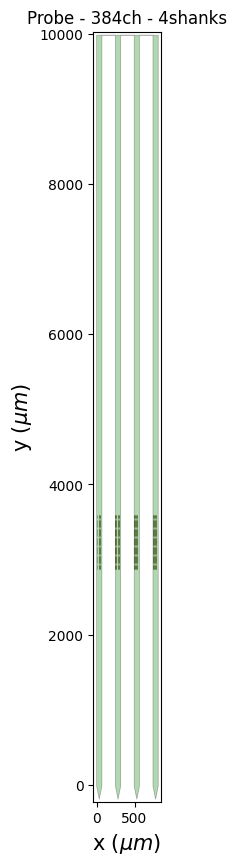

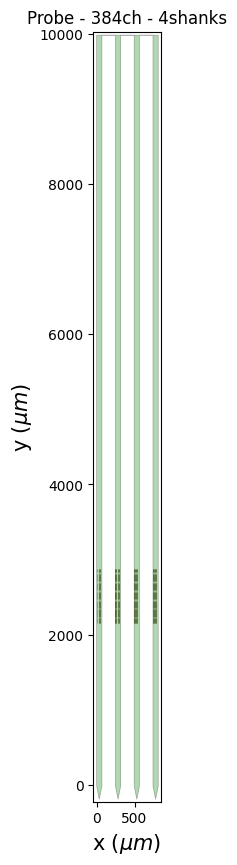

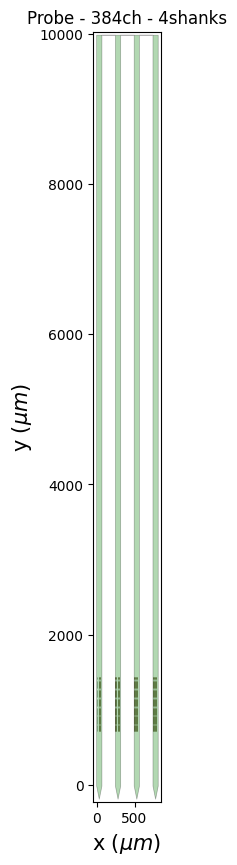

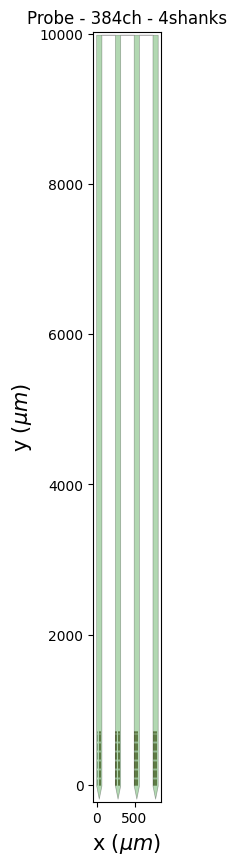

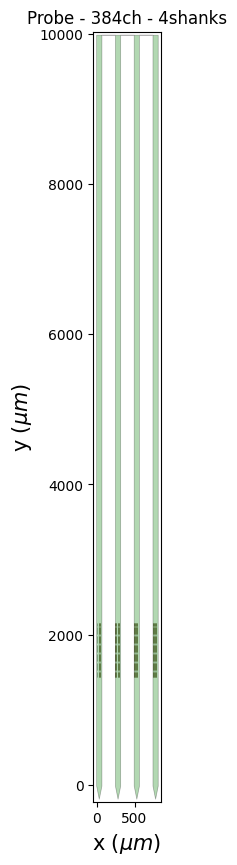

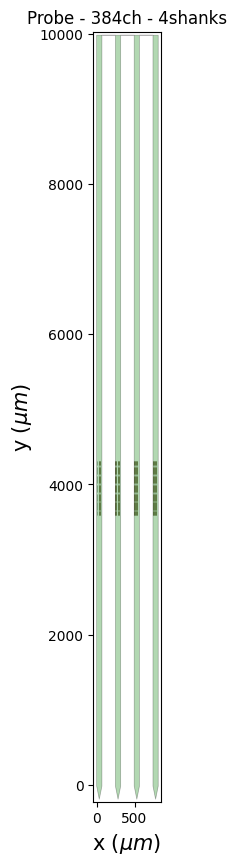

In [7]:
# run for each subject separately and sanity check the output plots have the correct channels selected
subject_ID = "ly05"
sps.save_probe_config_params(subject_ID=subject_ID)

processing config_5 for ly05 with
Assigning bad channels...
No outside_brain channels found on shank 1
No noisey channels found on shank 1
No dead channels found on shank 1
No outside_brain channels found on shank 2
No noisey channels found on shank 2
No dead channels found on shank 2
No outside_brain channels found on shank 3
No noisey channels found on shank 3
No dead channels found on shank 3
No outside_brain channels found on shank 4
1 noisey channel(s) found on shank 4
No dead channels found on shank 4
processing config_4 for ly05 with
Assigning bad channels...
No outside_brain channels found on shank 1
No noisey channels found on shank 1
No dead channels found on shank 1
No outside_brain channels found on shank 2
No noisey channels found on shank 2
No dead channels found on shank 2
No outside_brain channels found on shank 3
1 noisey channel(s) found on shank 3
No dead channels found on shank 3
No outside_brain channels found on shank 4
No noisey channels found on shank 4
No dead 

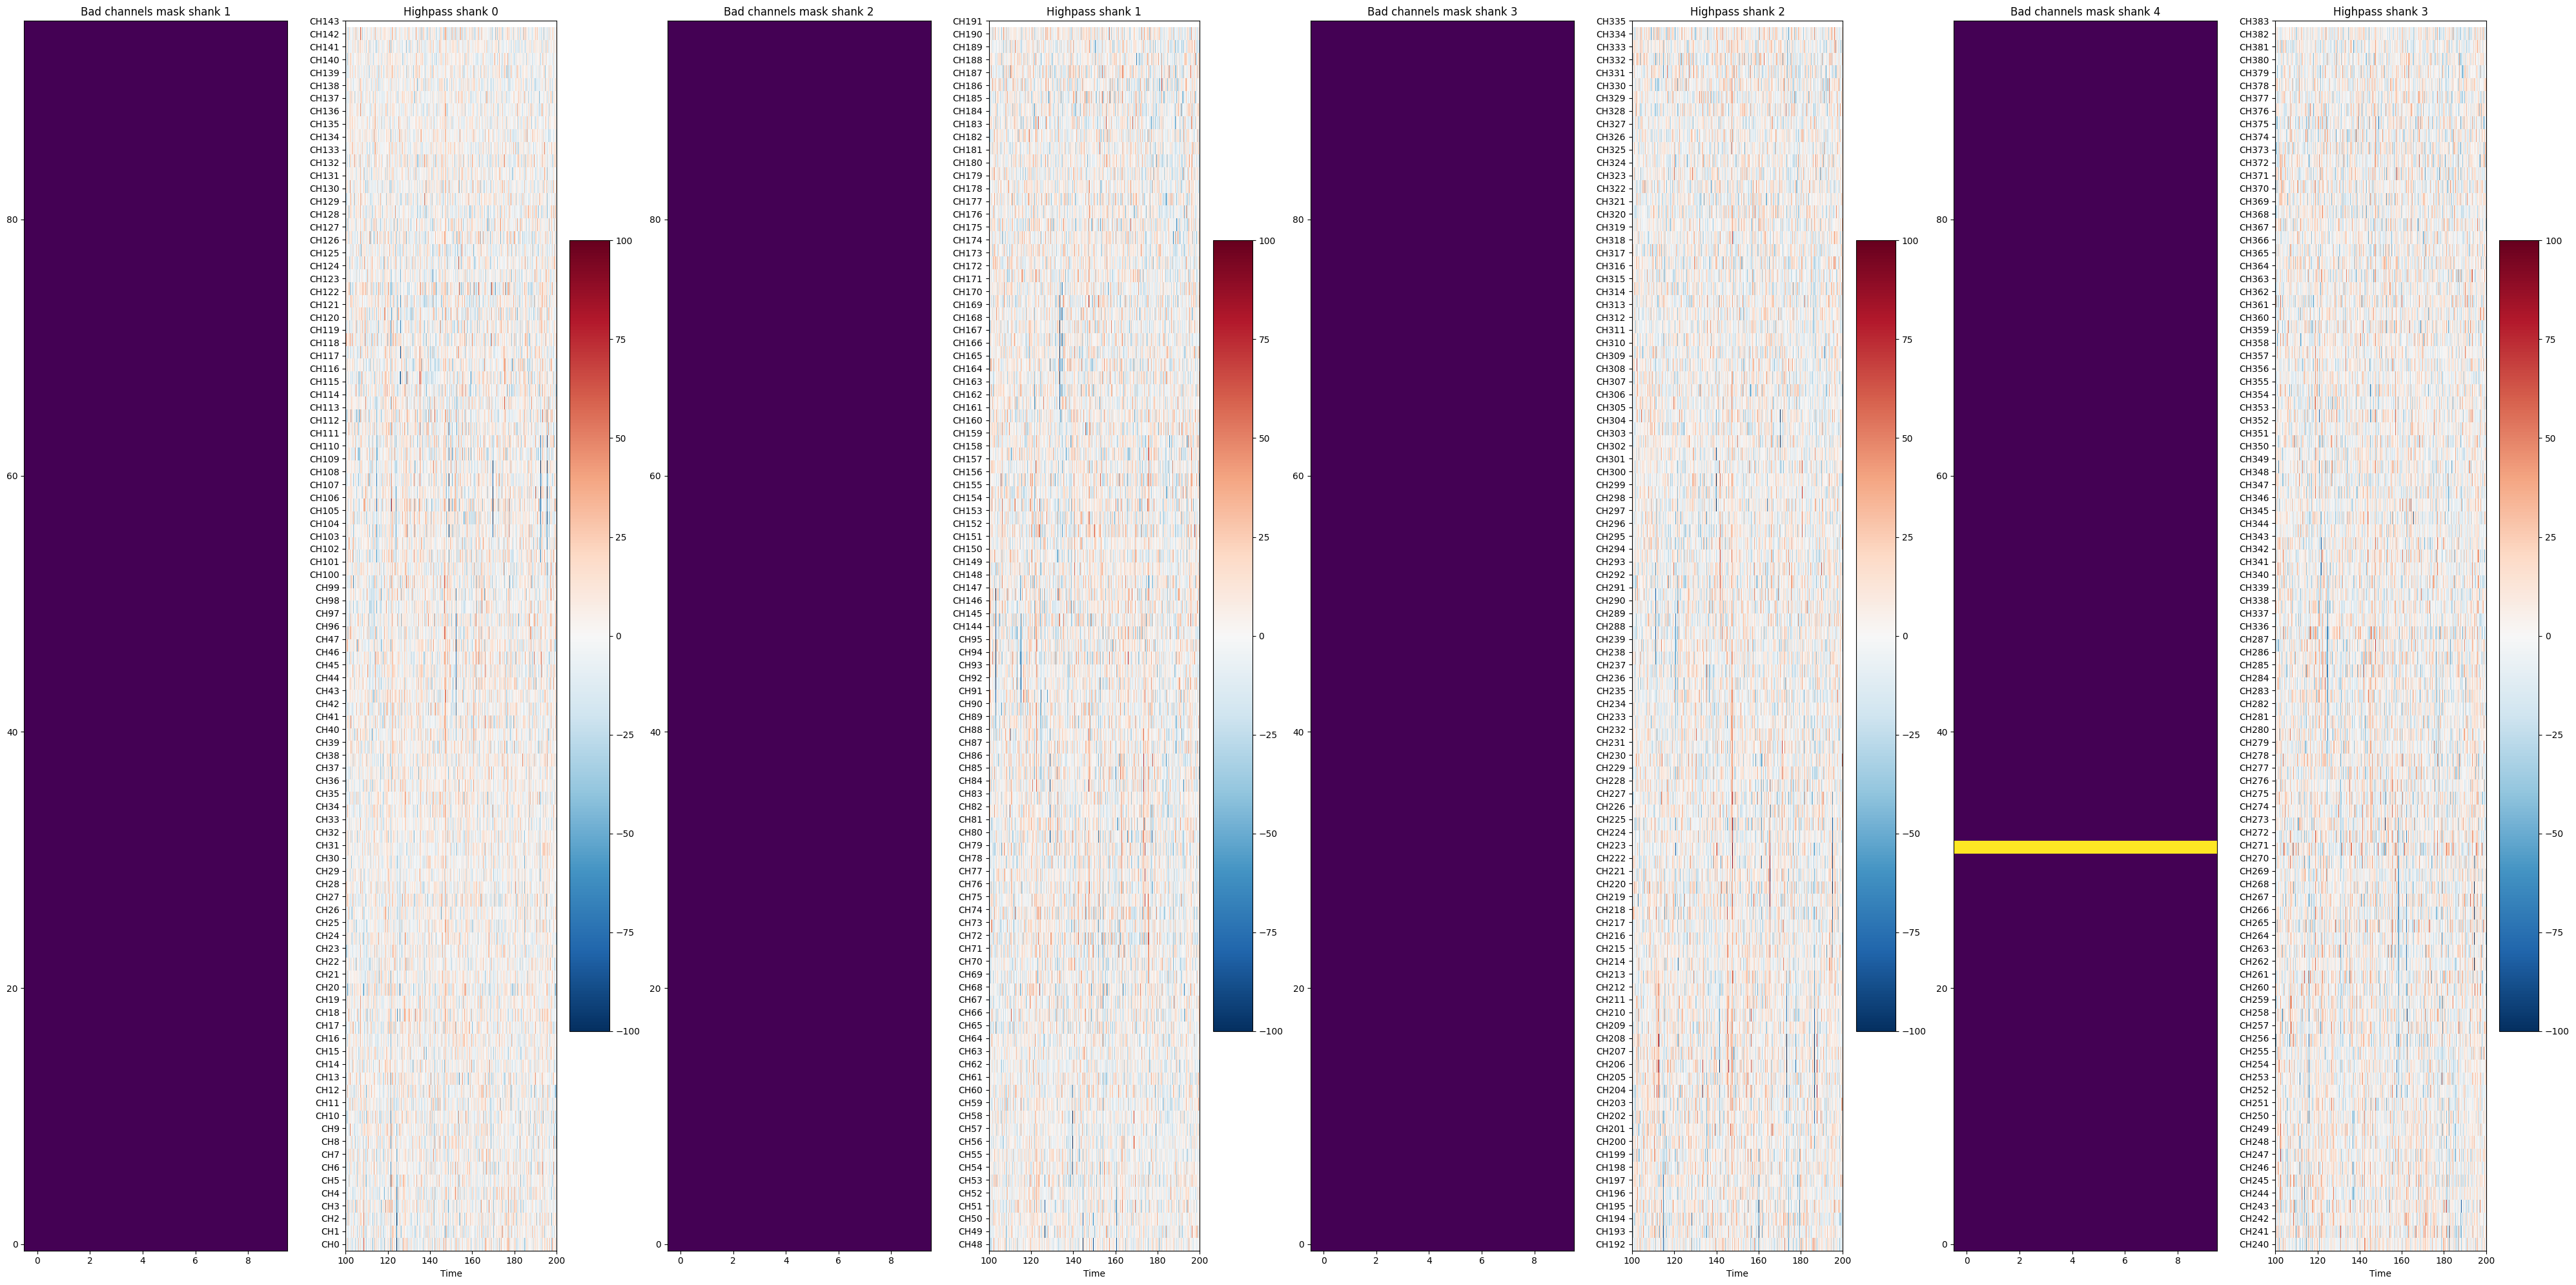

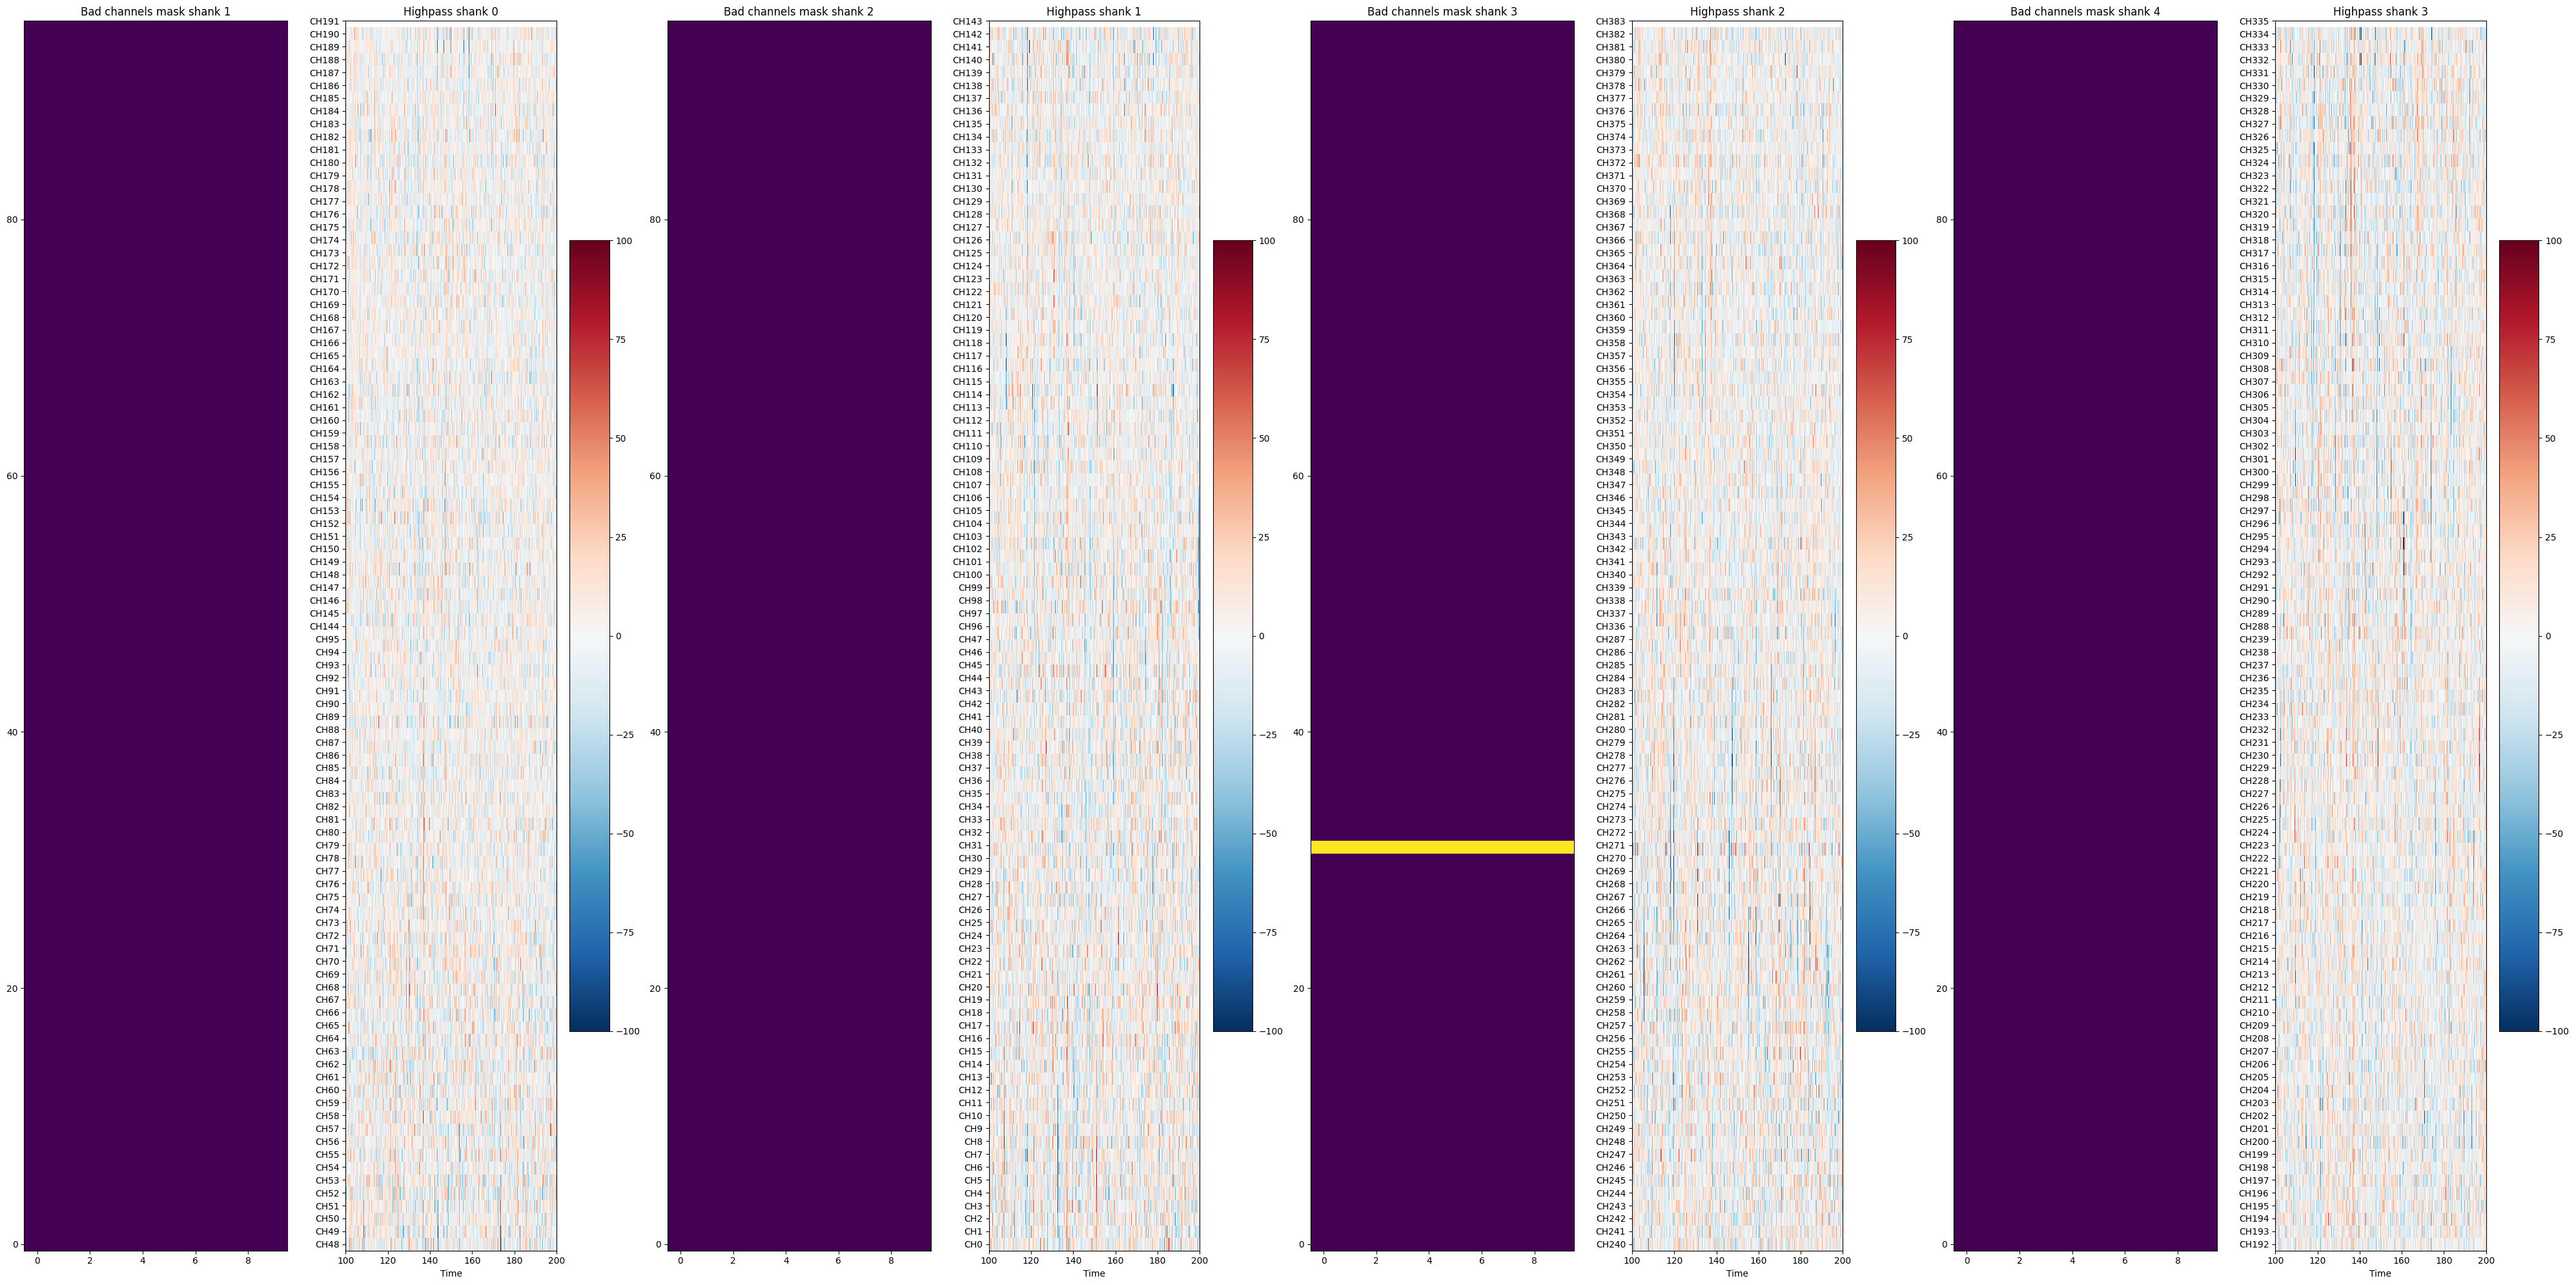

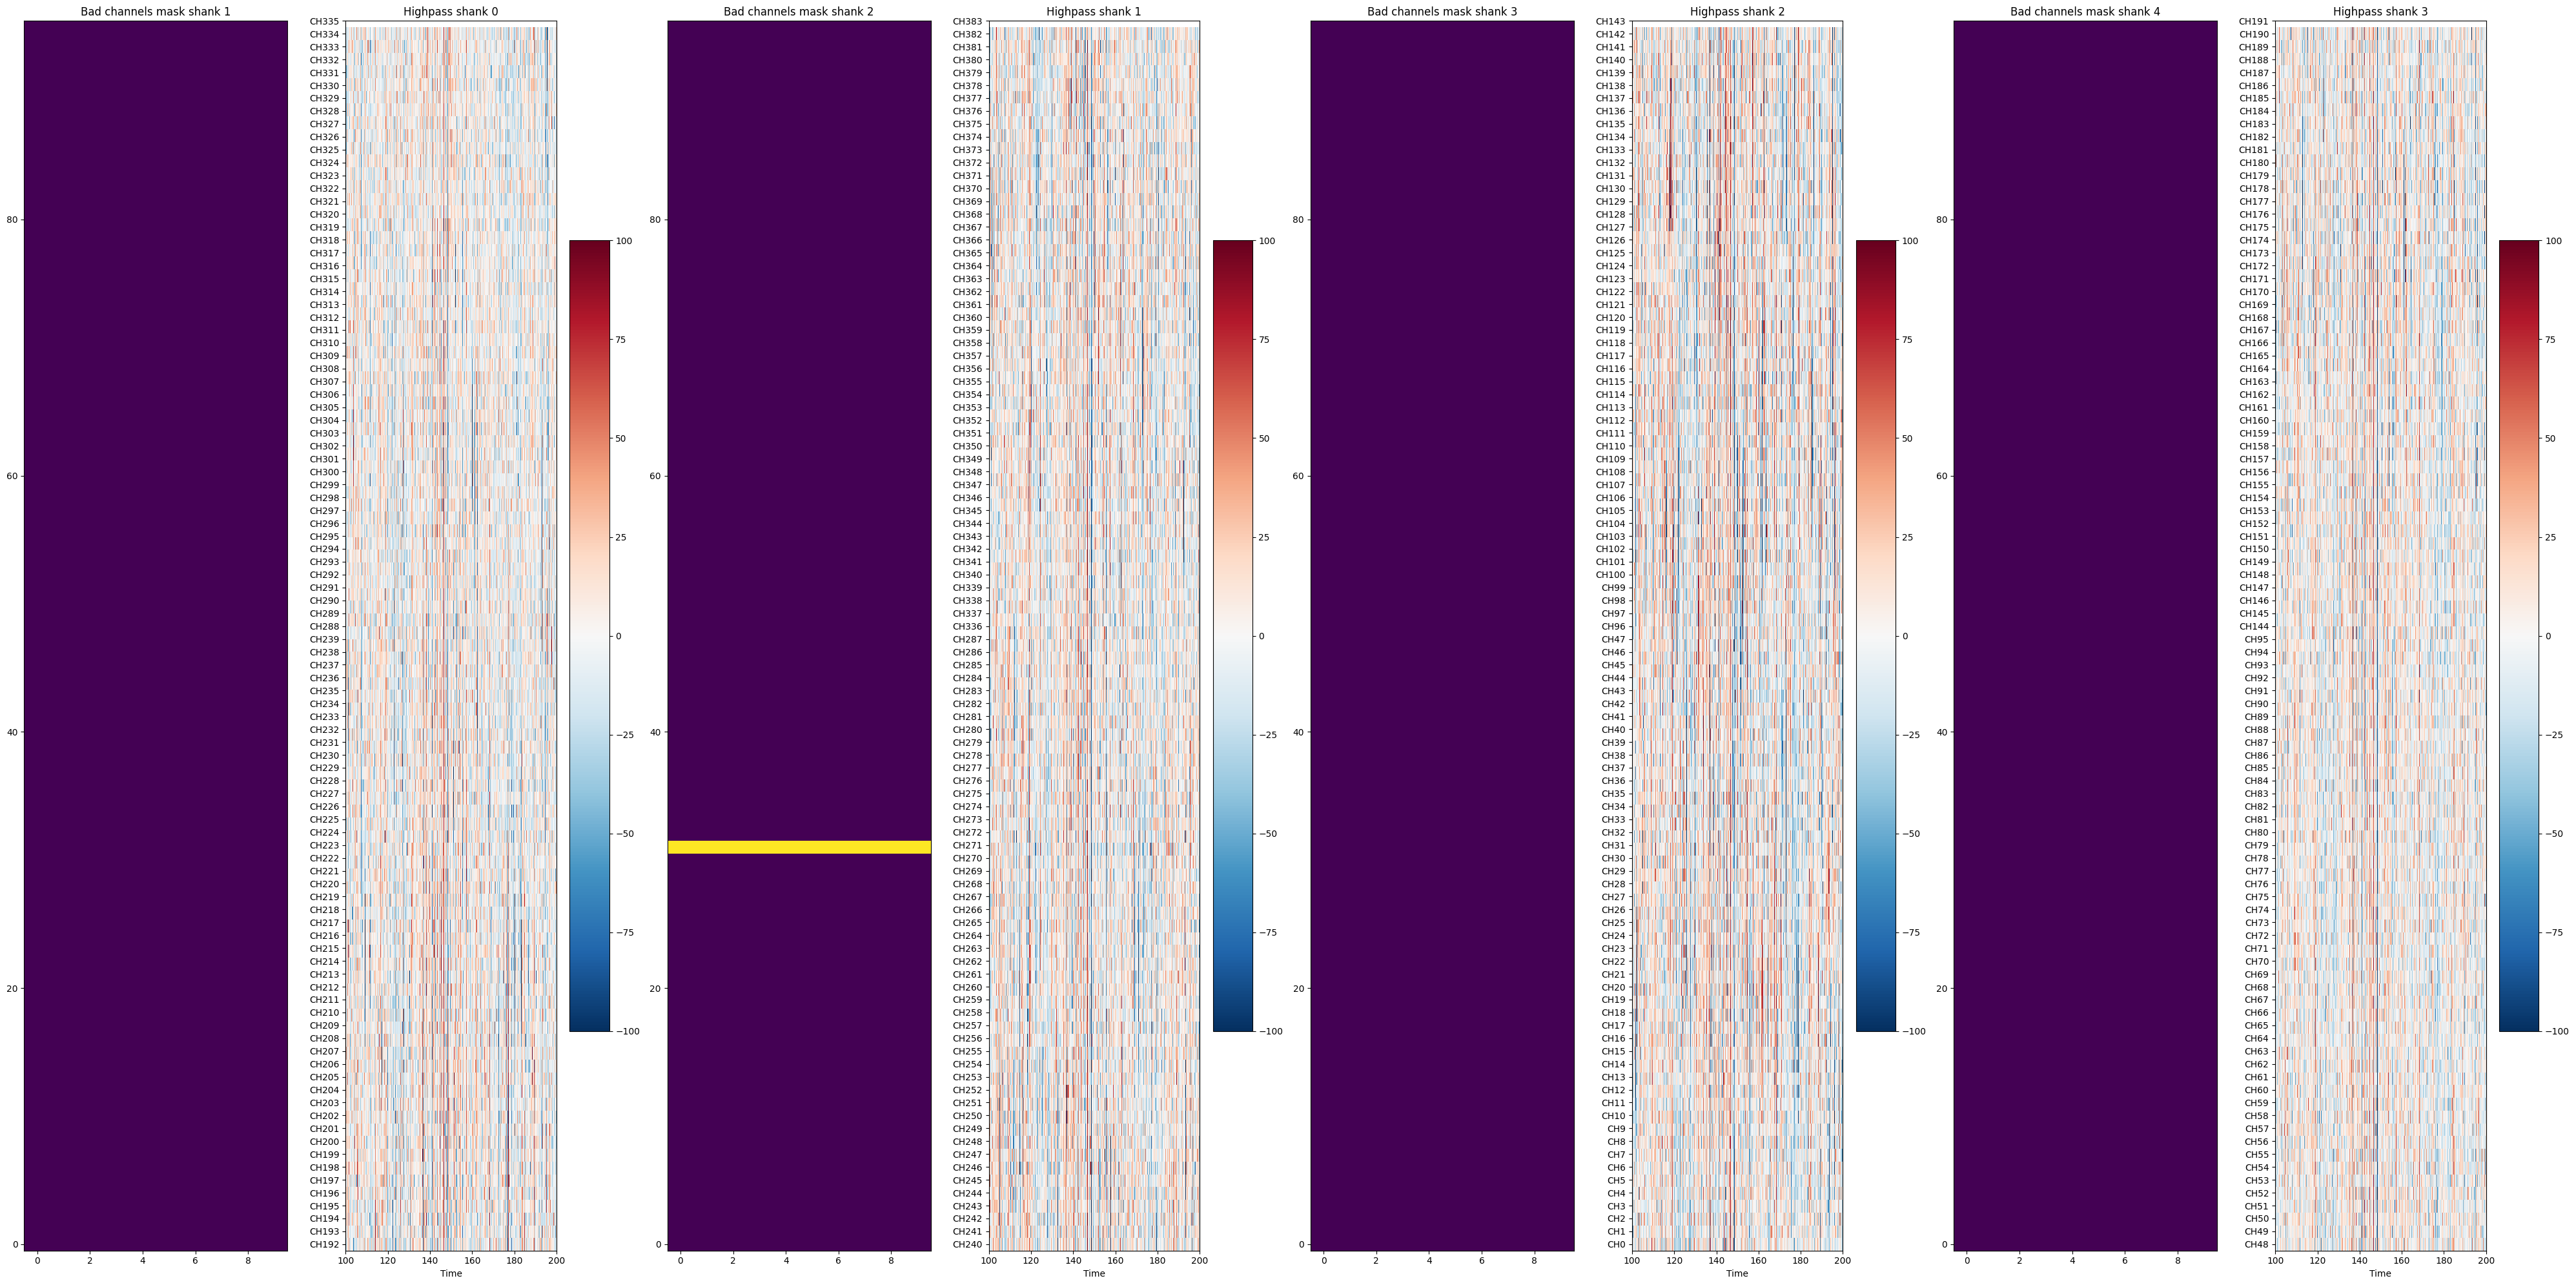

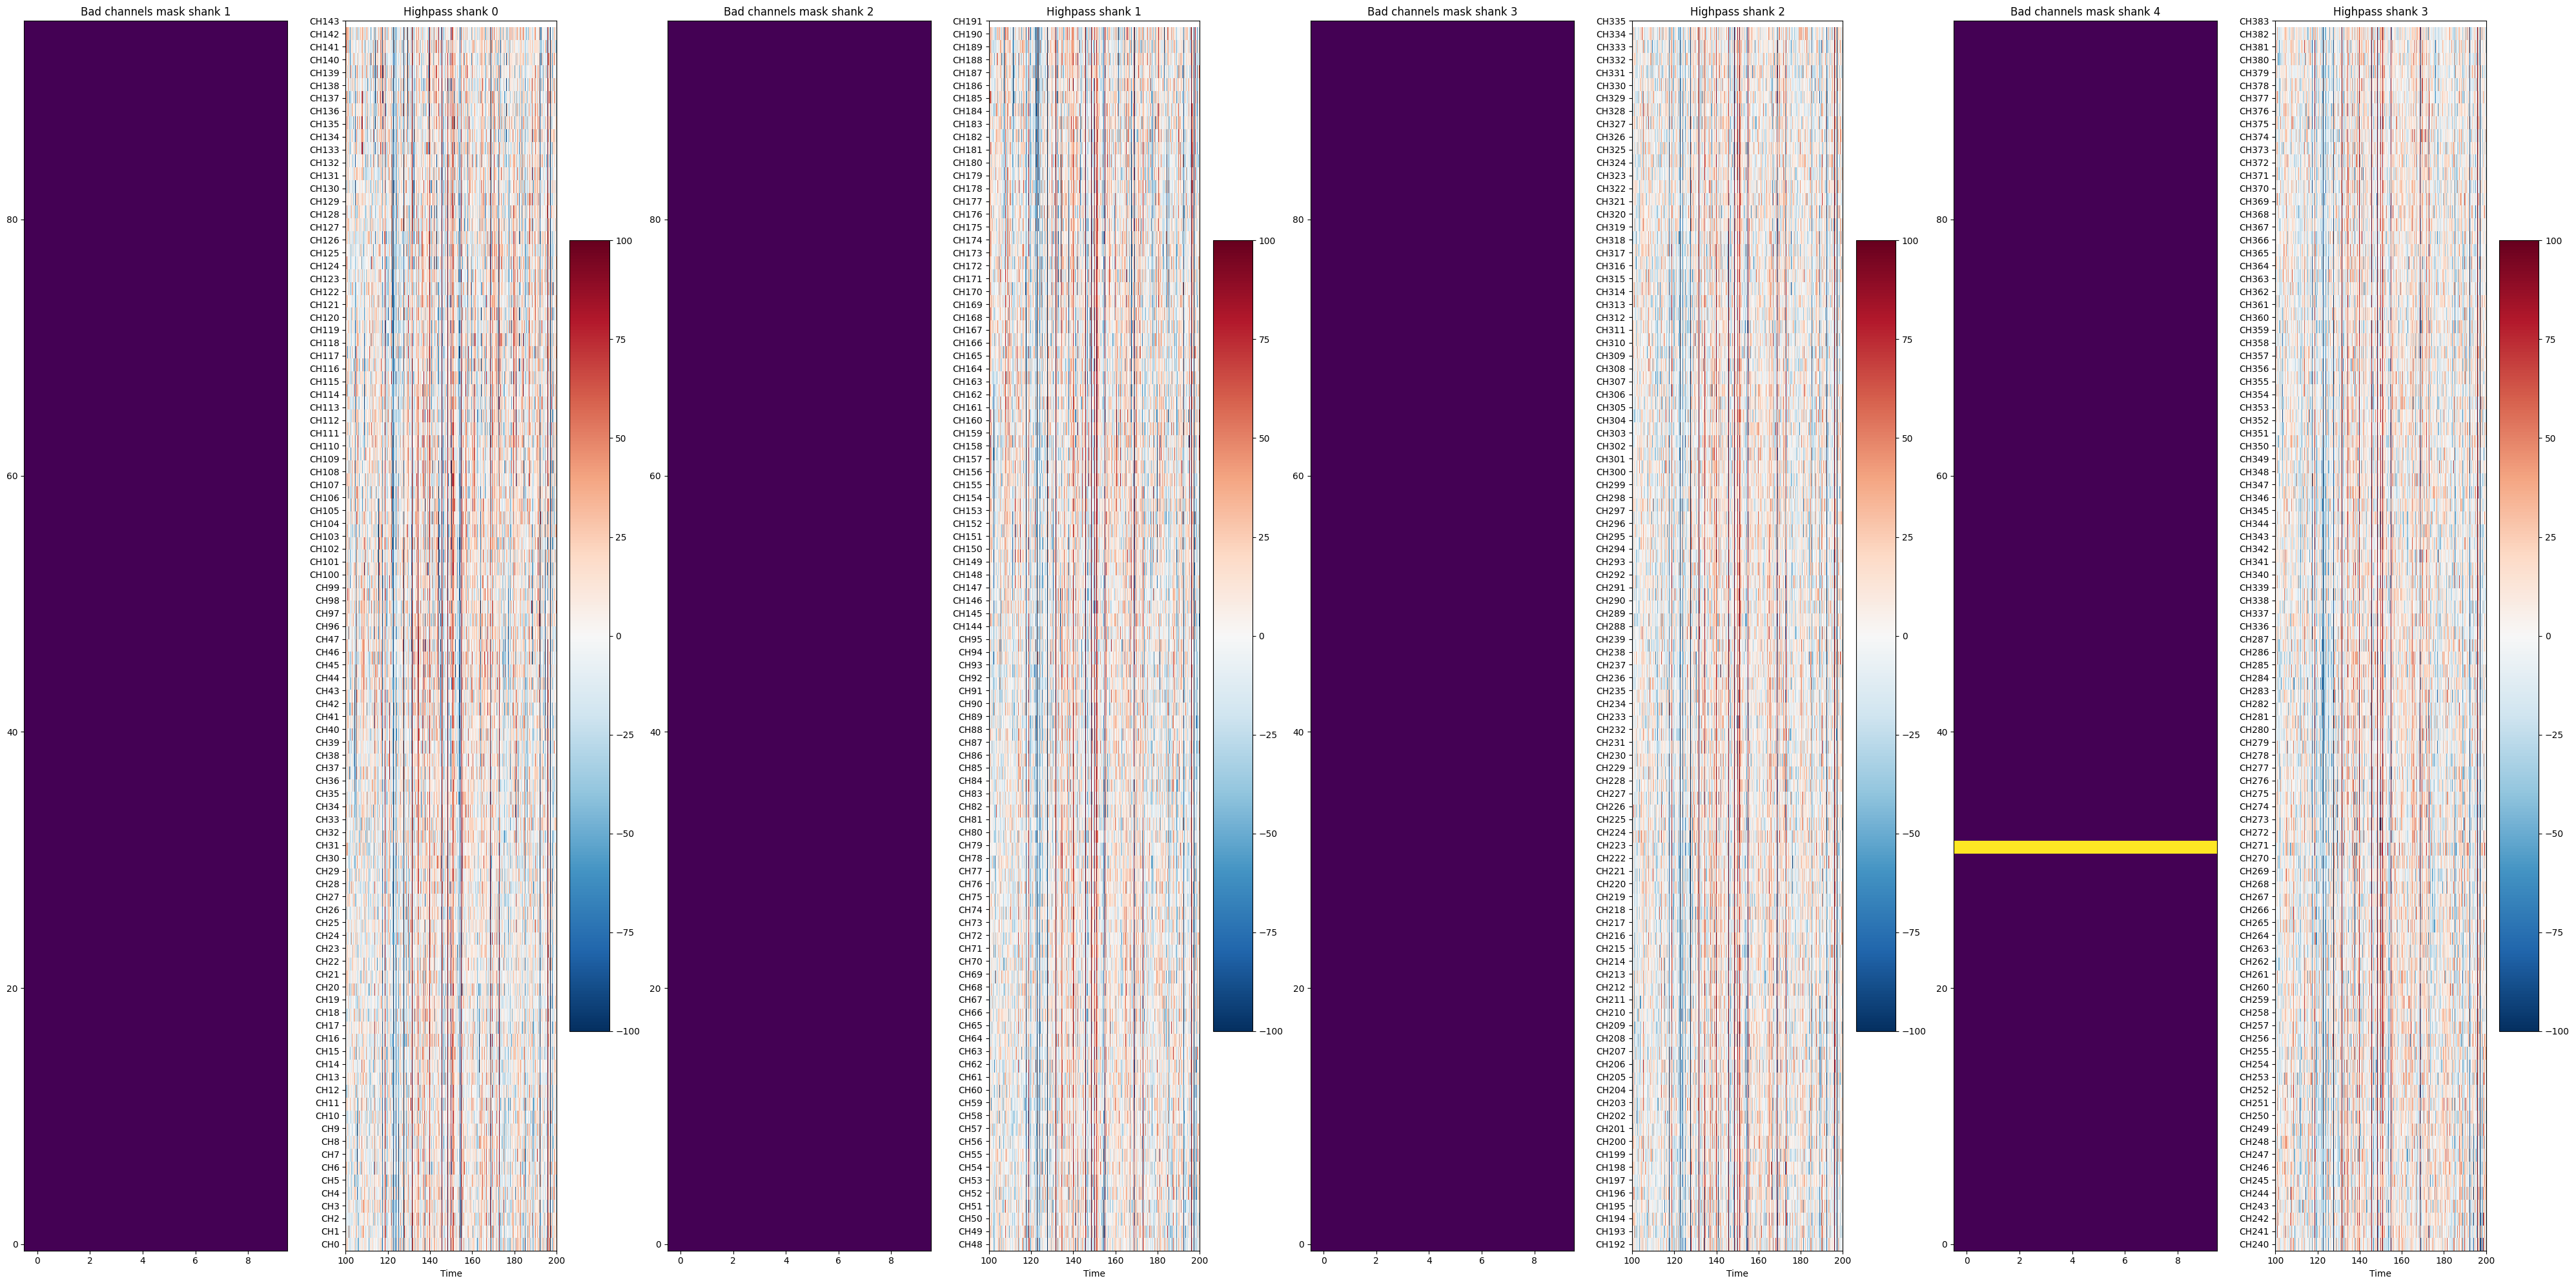

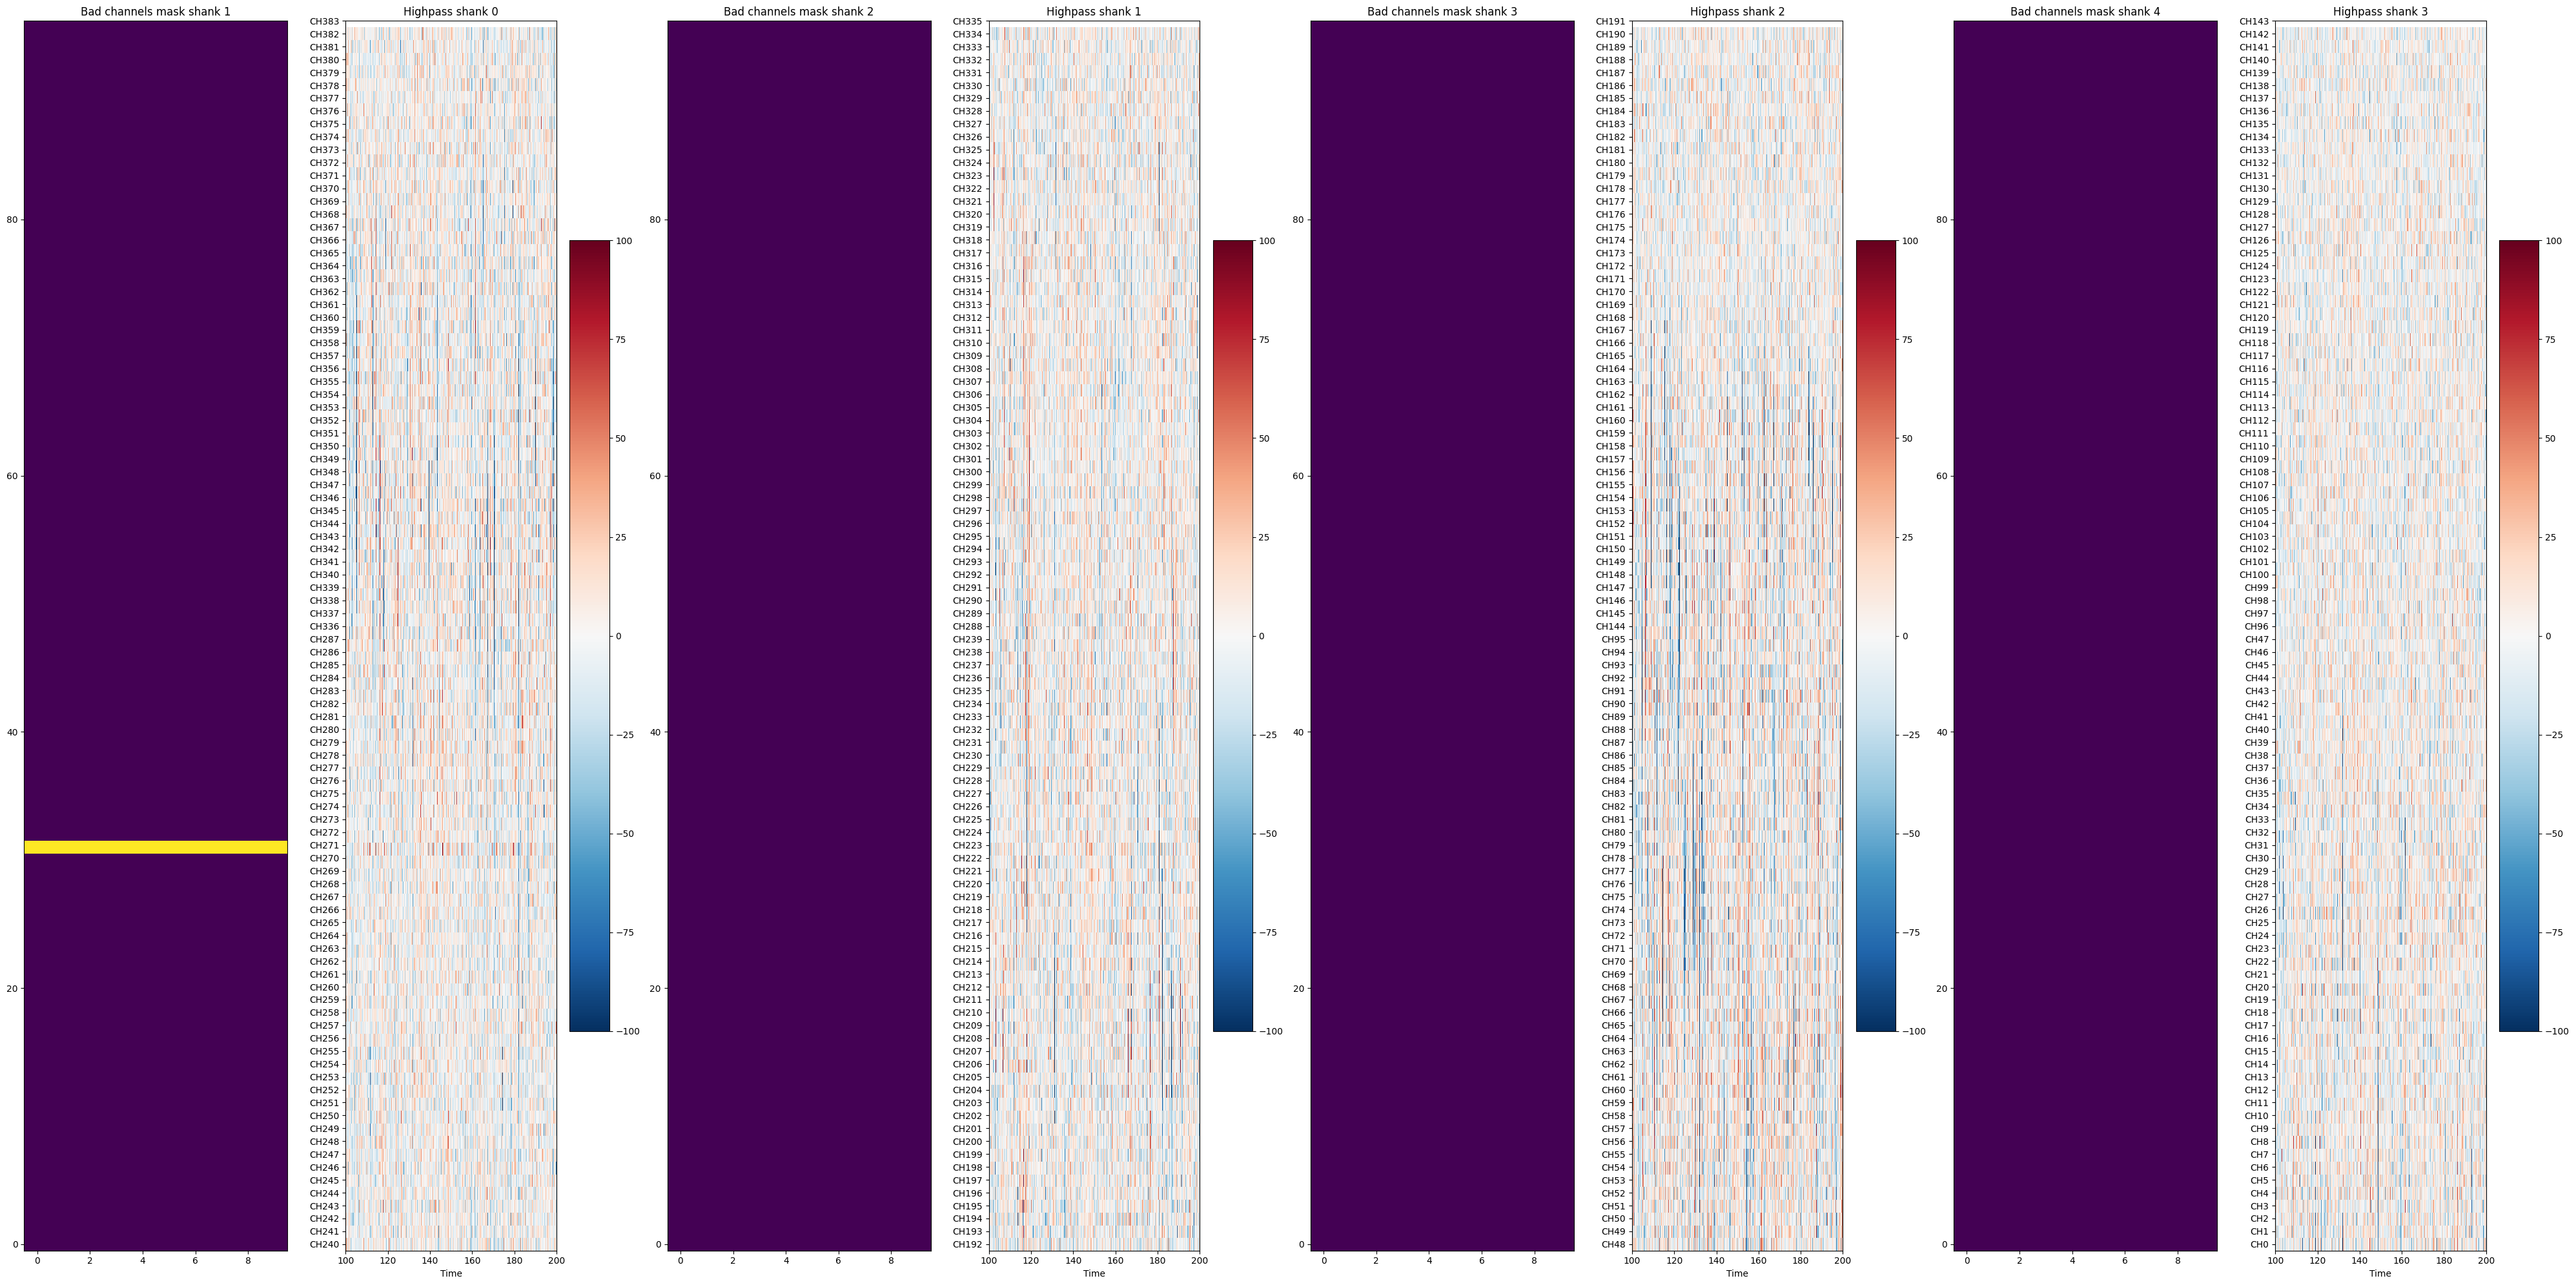

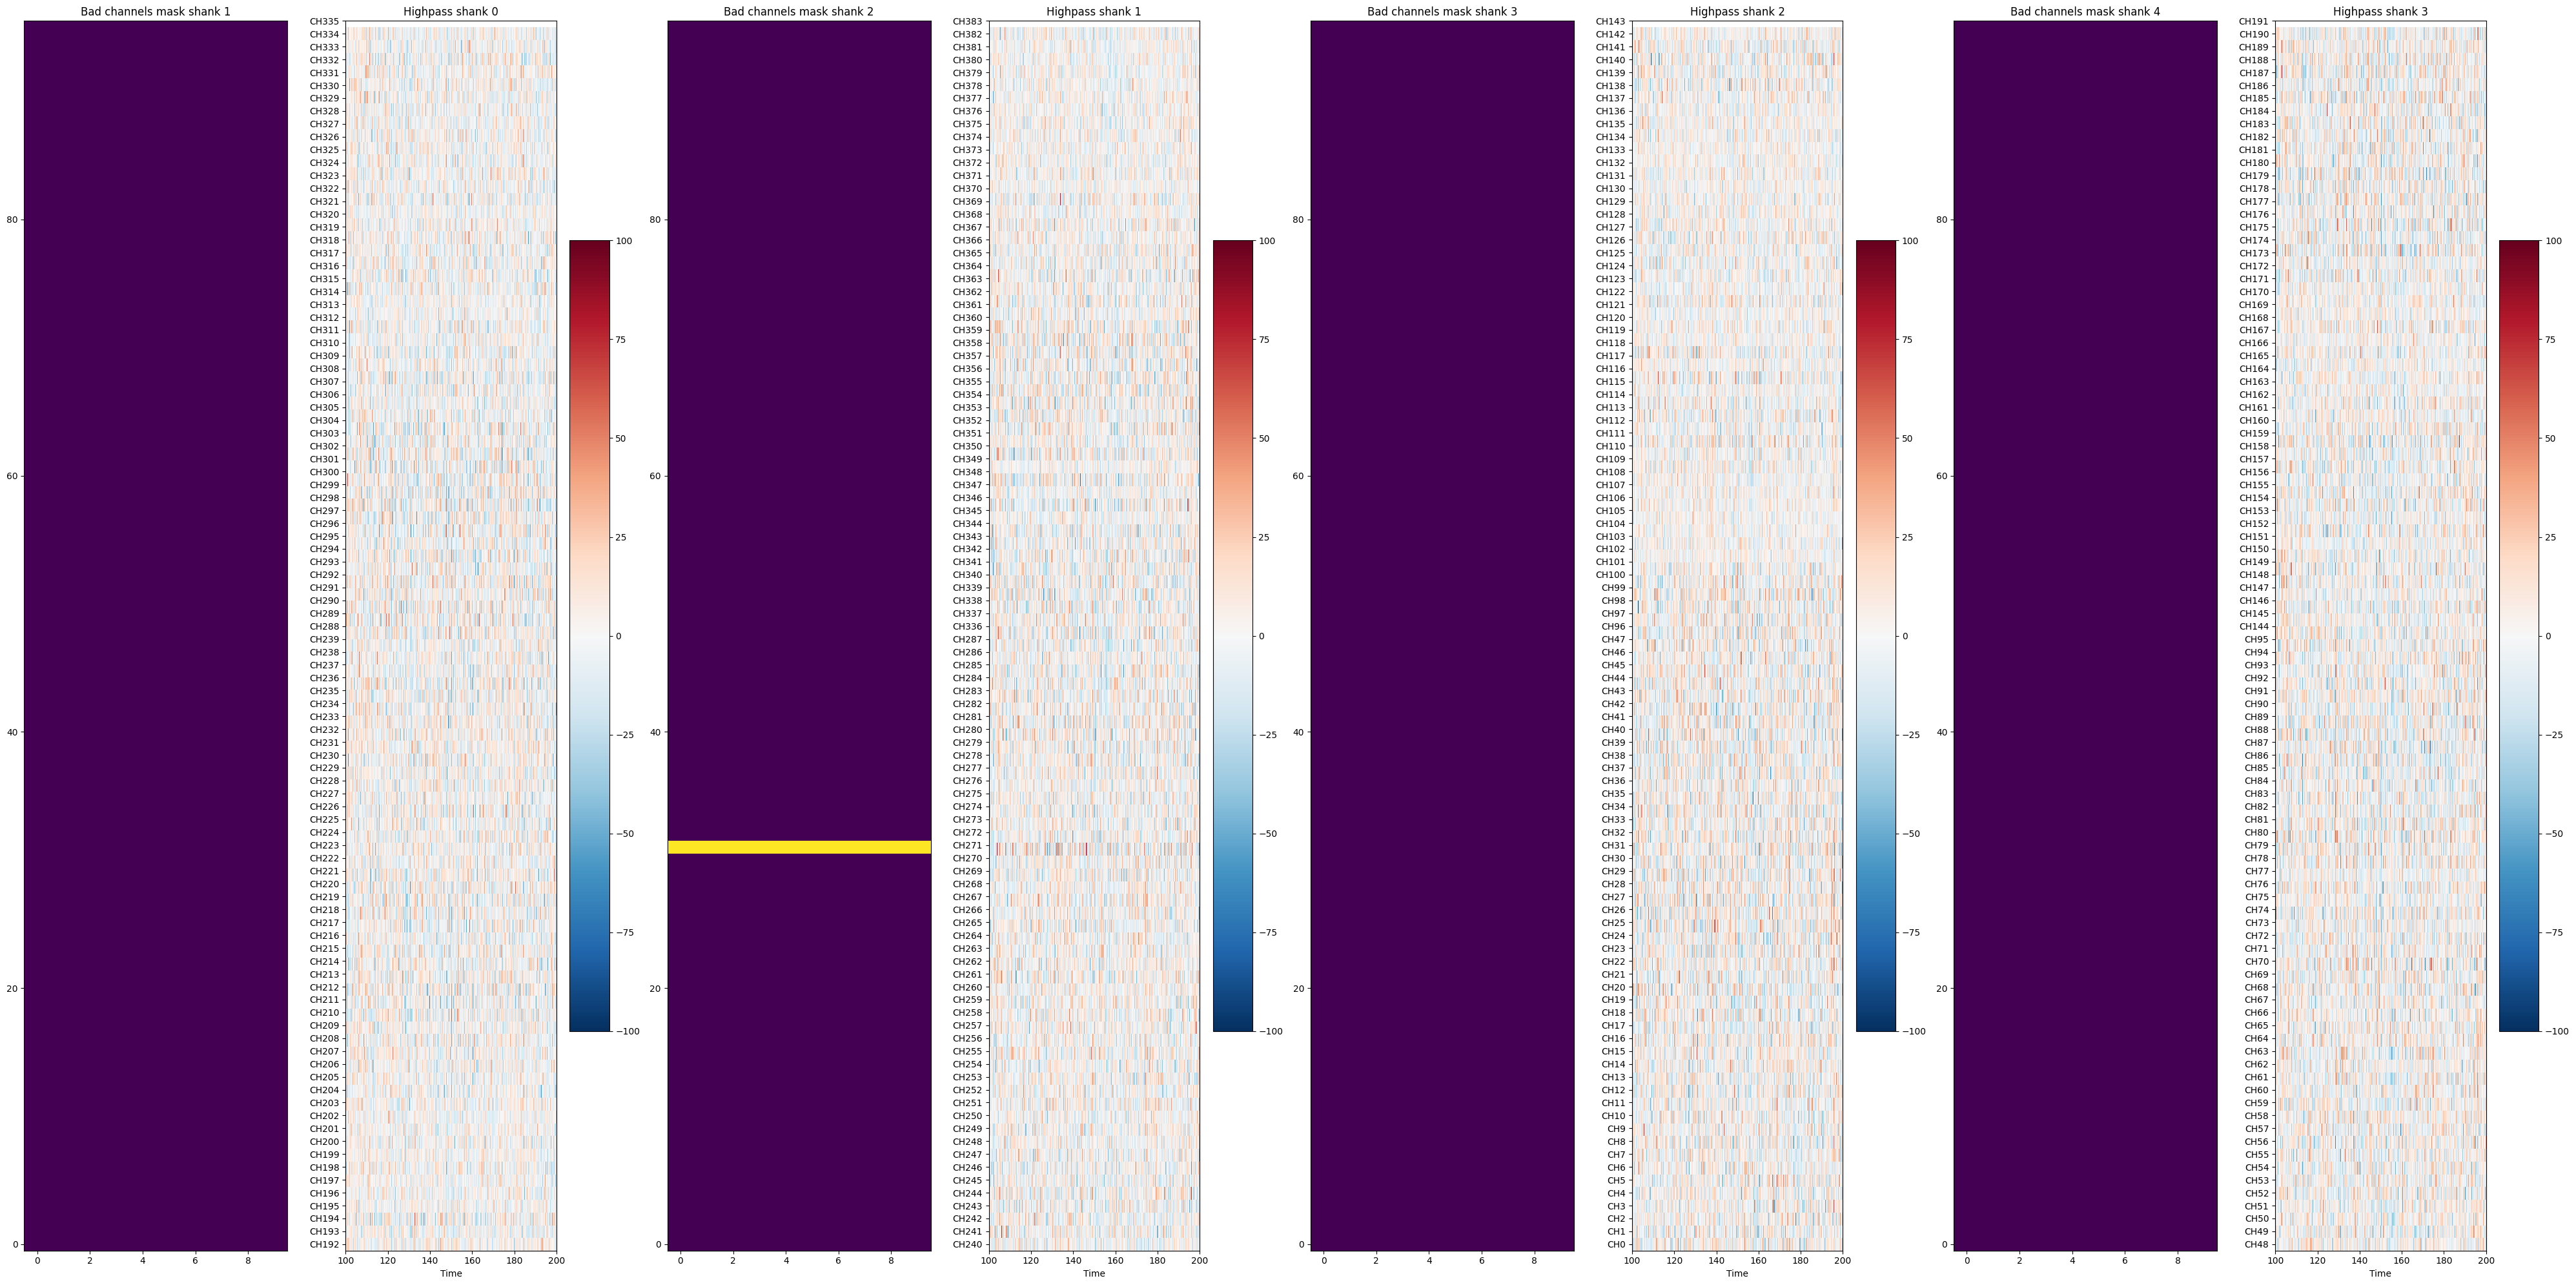

In [8]:
# same for this, just check the output plots are correctly detecting bad channels and outside brain channels (not relevent for LEC)
# can tweak outside_thresh and n_neighbours but will be unnessasry for these recordings
reload(sps)
sps.save_channel_assignment_params(subject_ID=subject_ID, outside_thresh=0.75, n_neighbours=11)

### STEP 3: Submit jobs to cluster!

In [9]:
reload(rep)
rep.run_ephys_preprocessing()

Submitting ly07 2025-06-01 15:51:09 to HPC
Submitting ly07 2025-06-01 15:34:53 to HPC
Submitted batch job 809784
Submitted batch job 809785
Submitting ly07 2025-06-01 15:02:27 to HPC
Submitted batch job 809786
Submitting ly07 2025-06-01 14:45:18 to HPC
Submitted batch job 809787
Submitting ly07 2025-06-01 15:18:36 to HPC
Submitted batch job 809788
Submitting ly05 2025-05-30 12:36:56 to HPC
Submitted batch job 809789
Submitting ly05 2025-05-30 12:20:13 to HPC
Submitted batch job 809790
Submitting ly05 2025-05-30 11:45:21 to HPC
Submitted batch job 809791
Submitting ly05 2025-05-30 11:29:09 to HPC
Submitted batch job 809792
Submitting ly05 2025-05-30 12:03:56 to HPC
Submitted batch job 809793
Submitting ly05 2025-05-30 12:54:38 to HPC
Submitted batch job 809794
All ephys preprocessing jobs submitted to HPC. Check progress with 'squeue -u <username>'


In [13]:
# monitor jobs
!squeue -u pdoohan

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
            809790      a100 ephys_pr  pdoohan PD       0:00      1 (Priority)
            809791      a100 ephys_pr  pdoohan PD       0:00      1 (Priority)
            809792      a100 ephys_pr  pdoohan PD       0:00      1 (Priority)
            809793      a100 ephys_pr  pdoohan PD       0:00      1 (Priority)
            809794      a100 ephys_pr  pdoohan PD       0:00      1 (Priority)
            809789      a100 ephys_pr  pdoohan PD       0:00      1 (Resources)
            809788      a100 ephys_pr  pdoohan  R       9:03      1 gpu-sr670-22
            809785      a100 ephys_pr  pdoohan  R      13:38      1 gpu-sr670-22
            809786      a100 ephys_pr  pdoohan  R      13:38      1 gpu-sr670-22
            809787      a100 ephys_pr  pdoohan  R      13:38      1 gpu-sr670-22
            809780      a100     bash  pdoohan  R    1:26:56      1 gpu-sr670-20
